In [155]:
import re
import sys
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer
from underthesea import word_tokenize

warnings.filterwarnings('ignore')
sys.path.append(os.path.abspath('..'))

from src.storage.db import get_connection

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [156]:
conn = get_connection()
df_raw = pd.read_sql('SELECT * FROM articles', conn)

def fix_text(x):
    if not isinstance(x, str):
        return x
    try:
        return x.encode('latin1').decode('utf-8')
    except:
        return x

for col in ['title', 'content']:
    df_raw[col] = df_raw[col].apply(fix_text)

print(f'Total rows loaded: {len(df_raw):,}')
df_raw.head(3)

Total rows loaded: 503


,id,source,title,url,image,published_at,crawled_at,content
0,1,vnexpress,"'Chậm một nhịp công nghệ, Việt Nam có thể lỡ c...",https://vnexpress.net/cham-mot-nhip-cong-nghe-...,https://i1-vnexpress.vnecdn.net/2026/04/20/202...,2026-04-20 09:34:24+00:00,2026-04-20 11:53:50.457832+00:00,"Tại phiên thảo luận hội trường chiều 20/4, đại..."
1,386,trainghiemso,Microsoft đang tạo ra một phiên bản OpenClaw khác,https://trainghiemso.vn/microsoft-dang-tao-ra-...,None,2026-04-14 01:41:53+00:00,2026-04-20 11:53:50.457832+00:00,Theo cÃ¡c bÃ¡o cÃ¡o má»i nháº¥t vÃ o thÃ¡ng 4...
2,55,vnexpress,Cách Trung Quốc chinh phục công nghệ tàu cao tốc,https://vnexpress.net/cach-trung-quoc-chinh-ph...,None,2026-04-15 04:41:51+00:00,2026-04-20 11:53:50.457832+00:00,Theo cuốnTốc độ của Trung Quốc: Phát triển Đườ...


In [157]:
df_raw.info()
df_raw.isnull().sum().rename('missing').to_frame()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype              
---  ------        --------------  -----              
 0   id            503 non-null    int64              
 1   source        503 non-null    object             
 2   title         503 non-null    object             
 3   url           503 non-null    object             
 4   image         212 non-null    object             
 5   published_at  503 non-null    datetime64[ns, UTC]
 6   crawled_at    503 non-null    datetime64[ns, UTC]
 7   content       492 non-null    object             
dtypes: datetime64[ns, UTC](2), int64(1), object(5)
memory usage: 31.6+ KB


,missing
id,0
source,0
title,0
url,0
image,291
published_at,0
crawled_at,0
content,11


In [158]:
df = df_raw.copy()
df['published_at'] = pd.to_datetime(df['published_at'], utc=True)

cutoff = pd.Timestamp.now(tz='UTC') - pd.Timedelta(days=7)
df = df[df['published_at'] >= cutoff].reset_index(drop=True)

df['content'] = df['content'].fillna('')
df['title']   = df['title'].fillna('')

print(f'Articles in past 7 days: {len(df):,}')
print(f'Date range: {df["published_at"].min().date()} -> {df["published_at"].max().date()}')

Articles in past 7 days: 191
Date range: 2026-04-13 -> 2026-04-20


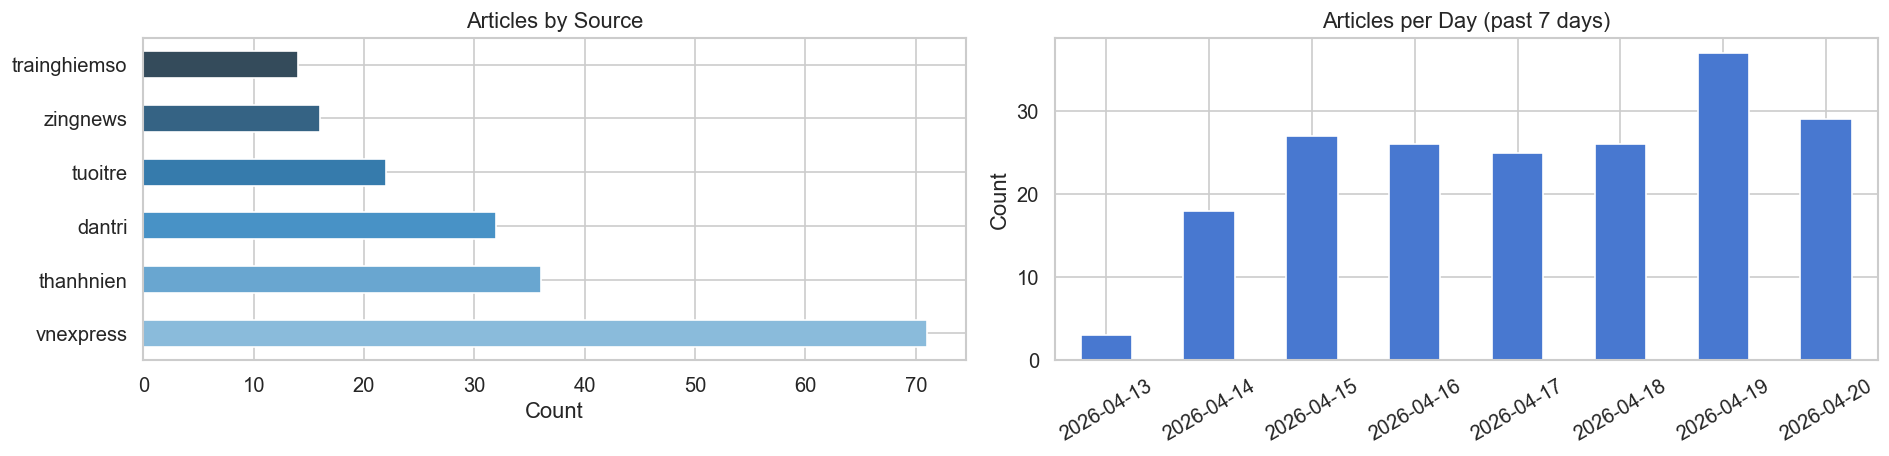

In [159]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

source_counts = df['source'].value_counts()
source_counts.plot(
    kind='barh', ax=axes[0],
    color=sns.color_palette('Blues_d', len(source_counts))
)
axes[0].set_title('Articles by Source')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('')

daily = df.groupby(df['published_at'].dt.date).size()
daily.plot(kind='bar', ax=axes[1], color=sns.color_palette('muted')[0])
axes[1].set_title('Articles per Day (past 7 days)')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [160]:
IMPORTANT_ENGLISH_KEYWORDS = {
    'ai', 'ml', 'llm', 'gpt', 'openai', 'chatgpt', 'github', 'python', 'java',
    'javascript', 'typescript', 'sql', 'api', 'web', 'app', 'ios', 'android',
    'cloud', 'aws', 'azure', 'google', 'meta', 'nvidia', 'tesla', 'apple',
    'samsung', 'iphone', 'bitcoin', 'ethereum', 'blockchain', 'nft', 'metaverse',
    'vr', 'ar', 'iot', 'ota', 'crm', 'erp', 'saas', 'paas', 'iaas', 'edge',
    'quantum', 'chip', '5g', '6g', 'cpu', 'gpu', 'ram', 'ssd', 'usb',
    'wifi', 'bluetooth', 'hdmi', 'usb-c', 'oled', 'amoled', 'refresh',
    'battery', 'megapixel', 'fps', 'fps', 'tps', 'latency', 'bandwidth',
    'vpn', 'proxy', 'firewall', 'encryption', 'hash', 'blockchain', 'zero-day',
    'exploit', 'malware', 'ransomware', 'trojan', 'worm', 'bot', 'ddos',
}

STOPWORDS = {
    'một_số','tuy_nhiên','đồng_thời','không_chỉ','thay_vì',
    'trong_khi','bên_cạnh','ngoài_ra','theo_đó','do_đó',
    'vì_vậy','mặc_dù','bởi_vì','chẳng_hạn','hay_là',
    'hơn','sao','tàu','kỳ','tận','ưu','tiên','nhân','ích',
    'gói','bộ','kho','nút','cúp','trẻ','già','gia','chủ',
    'thừa','khuyên','bắt','ép','mách','báo','kể','nói',

    'có_thể','sử_dụng','cho_phép','giúp_đỡ','thực_hiện',
    'xây_dựng','hoạt_động','tiếp_tục','bao_gồm','liên_quan',
    'tham_gia','chia_sẻ','thành_công','hiệu_quả','quan_trọng',

    'trong','của','với','tại','từ','theo','qua','bằng',
    'hay','còn','mà','nếu','khi','vì','để','là','và',
    'ra','vào','đến','lại','đã','sẽ','đang','được','bị',

    'một','những','nhiều','này','đây','các','cùng','đó',
    'như','sau','trên','cho','cần','có','không','làm',

    'người','người_dùng','sản_phẩm','dịch_vụ','công_ty',
    'hệ_thống','phát_triển','thiết_bị','tính_năng','khả_năng',
    'thông_tin','nội_dung','vấn_đề','trường_hợp','thời_gian',
    'việc','điều','cách','loại','số','mức','lần','công_nghệ',

    'năm','tháng','ngày','tuần','giờ',

    'http','https','www','com','vn','html','utm','org','net',

    'họ','ta','tôi','bạn','chúng','mình','anh','chị',

    'tp','hcm',

    'được','đang','sẽ','đã','phải','cần',
    'dùng','làm','tạo','cho','giúp','trợ','thực','thấy',
    'hoặc','và','nhưng','nếu','vì','nên',
    'mới','cũ','lớn','nhỏ','tốt','xấu','nhanh',

    'dân_trí','vnexpress','thanh_niên','tuổi_trẻ','báo_chí',
    'trang_web','website','công_bố','thông_báo','tin_tức'
}

MOJIBAKE_TERMS = ['thá', 'á_ng', 'á_c', 'cã³', 'thã', 'láñ', 'lá¡', 'ã¡', 'ã©', 'ã³', 'ãº']

def has_mojibake(text: str) -> bool:
    if not isinstance(text, str):
        return False
    count = sum(text.count(term) for term in MOJIBAKE_TERMS)
    return count > 0

def clean_text(text: str) -> str:
    text = re.sub(r'https?://\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'[^\w\s]', ' ', text, flags=re.UNICODE)
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def remove_stopwords(tokenized_text: str) -> str:
    tokens = tokenized_text.split()
    filtered = []
    for t in tokens:
        is_english = t.isascii() and t.isalpha()
        is_important_english = t.lower() in IMPORTANT_ENGLISH_KEYWORDS
        
        if is_important_english:
            filtered.append(t)
        elif (
            t not in STOPWORDS
            and len(t) > 2
            and not t.isnumeric()
            and not is_english
        ):
            filtered.append(t)
    return ' '.join(filtered)

df['text_raw'] = (df['title'] + ' ' + df['content']).str.lower()
df['text_clean'] = df['text_raw'].apply(clean_text)
df['mojibake_count'] = df['text_clean'].apply(lambda x: sum(x.count(term) for term in MOJIBAKE_TERMS))
df['tokenized'] = df['text_clean'].apply(lambda x: word_tokenize(x, format='text'))
df['tokenized'] = df['tokenized'].apply(remove_stopwords)

df = df[df['mojibake_count'] < 2].drop('mojibake_count', axis=1).reset_index(drop=True)

print(f'Articles after mojibake filter: {len(df):,}')
print(df['tokenized'].iloc[0][:200])
print(df['tokenized'].str.split().str.len().mean())

Articles after mojibake filter: 114
cải_tiến phiên_bản củastart menutrên năm_ngoái nhằm đáp_ứng phản_hồi bổ_sung cần_thiết yêu_cầu lâu phiên_bản cải_thiện đáng_kể bản phát_hành vẫn thiếu nhất ảnh chụp màn_hình giờ_đây cải_tiến nữa báo_c
144.5438596491228


In [161]:
tfidf = TfidfVectorizer(
    max_features=500,
    ngram_range=(2, 2),
    stop_words=list(STOPWORDS),
    token_pattern=r'(?u)\b\w\w+\b',
    min_df=2,
)
tfidf_matrix = tfidf.fit_transform(df['tokenized'])
tfidf_scores = dict(zip(
    tfidf.get_feature_names_out(),
    tfidf_matrix.mean(axis=0).A1
))

top50_df = pd.DataFrame(
    sorted(tfidf_scores.items(), key=lambda x: x[1], reverse=True)[:50],
    columns=['keyword', 'tfidf_score']
)
print('Top 50 TF-IDF keywords (raw, pre-semantic filter):')
top50_df.head(50)

Top 50 TF-IDF keywords (raw, pre-semantic filter):


,keyword,tfidf_score
0,thuê di_động,0.044548
1,ảnh chụp,0.028860
2,xác_thực thuê,0.027769
3,chụp màn_hình,0.025202
4,mạng xã_hội,0.022554
5,trí_tuệ nhân_tạo,0.021869
6,bản cập_nhật,0.020340
7,bên cạnh,0.020060
8,lên tới,0.019846
9,đáng chú_ý,0.018778


In [162]:
MODEL_NAME = 'keepitreal/vietnamese-sbert'
sbert = SentenceTransformer(MODEL_NAME)
print(f'Model loaded: {MODEL_NAME}')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17175.97it/s]
RobertaModel LOAD REPORT from: keepitreal/vietnamese-sbert
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded: keepitreal/vietnamese-sbert


In [163]:
TECH_QUERIES = [
    'trí tuệ nhân tạo AI machine learning deep learning mô hình huấn luyện neural network chatgpt openai',
    'điện thoại smartphone iphone samsung phần cứng chip vi xử lý màn hình camera công nghệ di động',
    'phần mềm ứng dụng lập trình code phát triển backend frontend nền tảng xây dựng',
    'an ninh mạng bảo mật dữ liệu hacker tấn công mã hóa firewall bảo vệ',
    'xe điện năng lượng xanh pin sạc công nghệ pin pin lithium xe tự lái',
    'mạng xã hội facebook tiktok youtube instagram nền tảng internet kết nối người dùng',
    'khởi nghiệp startup công ty công nghệ đầu tư gọi vốn cổ phiếu niêm yết',
    'máy tính cá nhân laptop desktop máy chủ server công nghệ máy tính',
    'internet vật lý iot sensor kết nối thiết bị thông minh nhà thông minh',
    'blockchain tiền điện tử bitcoin ethereum công nghệ phân tán ledger',
]

texts_for_embed = (df['title'] + ' ' + df['content']).tolist()
article_embeddings = sbert.encode(texts_for_embed, batch_size=64, show_progress_bar=True, normalize_embeddings=True)
query_embeddings = sbert.encode(TECH_QUERIES, normalize_embeddings=True)

sim_matrix = cosine_similarity(article_embeddings, query_embeddings)
df['tech_score'] = np.sort(sim_matrix, axis=1)[:, -2:].mean(axis=1)
df['tech_topic'] = [TECH_QUERIES[i] for i in sim_matrix.argmax(axis=1)]

df[['title', 'source', 'tech_score', 'tech_topic']].sort_values('tech_score', ascending=False).head(10)
print(f"Score range: {df['tech_score'].min():.3f} - {df['tech_score'].max():.3f}")

Batches: 100%|██████████| 2/2 [00:17<00:00,  8.94s/it]


Score range: 0.153 - 0.539


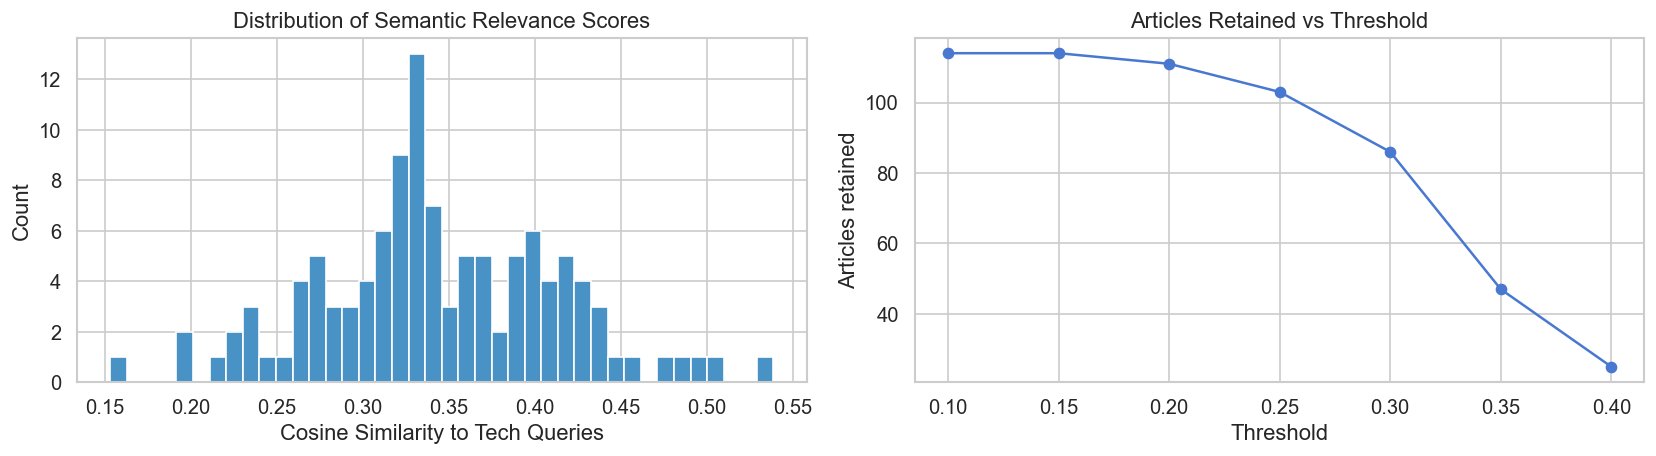

 threshold  n_articles
      0.10         114
      0.15         114
      0.20         111
      0.25         103
      0.30          86
      0.35          47
      0.40          25

Selected threshold: 0.25  ->  103 / 114 articles


In [164]:
thresholds = np.arange(0.10, 0.45, 0.05)
coverage = [(t, (df['tech_score'] >= t).sum()) for t in thresholds]
cov_df = pd.DataFrame(coverage, columns=['threshold', 'n_articles'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['tech_score'], bins=40, color=sns.color_palette('Blues_d')[2], edgecolor='white')
axes[0].set_title('Distribution of Semantic Relevance Scores')
axes[0].set_xlabel('Cosine Similarity to Tech Queries')
axes[0].set_ylabel('Count')

axes[1].plot(cov_df['threshold'], cov_df['n_articles'], marker='o', color=sns.color_palette('muted')[0])
axes[1].set_title('Articles Retained vs Threshold')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Articles retained')
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(cov_df.to_string(index=False))

THRESHOLD = 0.25
df_tech = df[df['tech_score'] >= THRESHOLD].reset_index(drop=True)
print(f'\nSelected threshold: {THRESHOLD}  ->  {len(df_tech):,} / {len(df):,} articles')


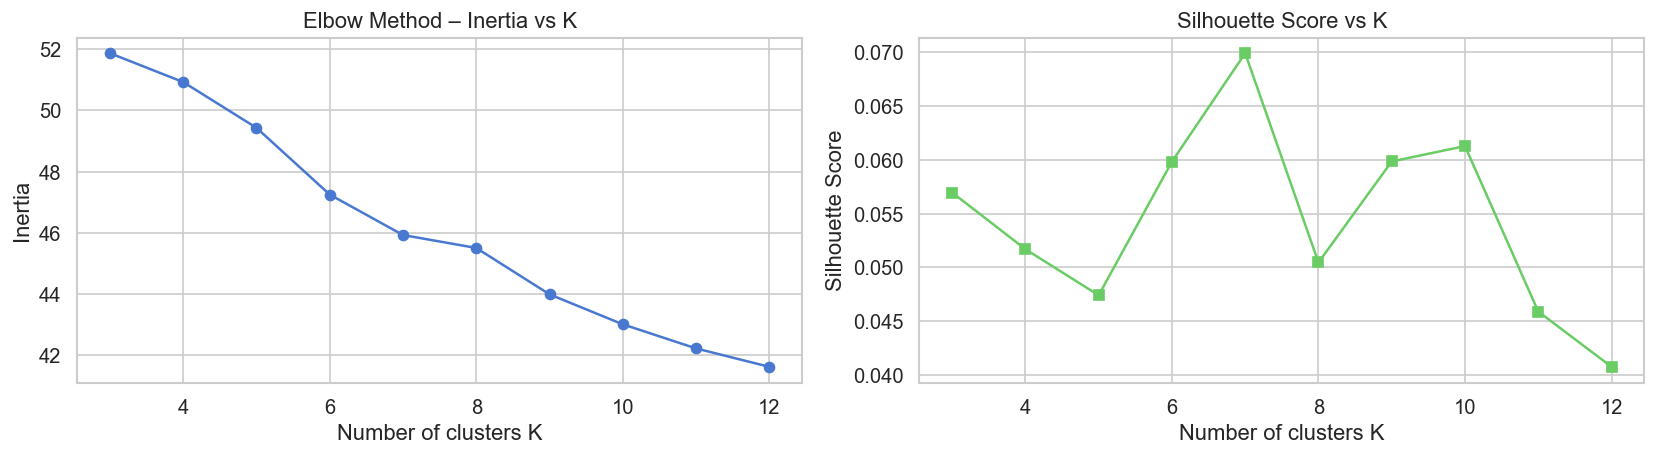

Best K by silhouette: 3  (score=0.0699)
 k   inertia  silhouette
 3 51.863503    0.056945
 4 50.920937    0.051695
 5 49.427505    0.047424
 6 47.248367    0.059807
 7 45.928436    0.069855
 8 45.505962    0.050463
 9 43.991615    0.059823
10 43.014034    0.061248
11 42.226986    0.045919
12 41.626541    0.040795

Articles per cluster:
         count
cluster       
0           43
1           27
2           33


In [165]:
from sklearn.metrics import silhouette_score

tech_embeddings = article_embeddings[df['tech_score'] >= THRESHOLD]

K_RANGE = range(3, 13)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = km.fit_predict(tech_embeddings)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(tech_embeddings, labels, sample_size=min(2000, len(labels)), random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(list(K_RANGE), inertias, marker='o', color=sns.color_palette('muted')[0])
axes[0].set_title('Elbow Method – Inertia vs K')
axes[0].set_xlabel('Number of clusters K')
axes[0].set_ylabel('Inertia')
axes[0].grid(True)

axes[1].plot(list(K_RANGE), sil_scores, marker='s', color=sns.color_palette('muted')[2])
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of clusters K')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True)

plt.tight_layout()
plt.show()

N_CLUSTERS = 3 # int(np.argmax(sil_scores)) + K_RANGE.start
print(f'Best K by silhouette: {N_CLUSTERS}  (score={max(sil_scores):.4f})')

results_df = pd.DataFrame({'k': list(K_RANGE), 'inertia': inertias, 'silhouette': sil_scores})
print(results_df.to_string(index=False))

kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init='auto')
df_tech['cluster'] = kmeans.fit_predict(tech_embeddings)

print('\nArticles per cluster:')
print(df_tech['cluster'].value_counts().sort_index().rename('count').to_frame())


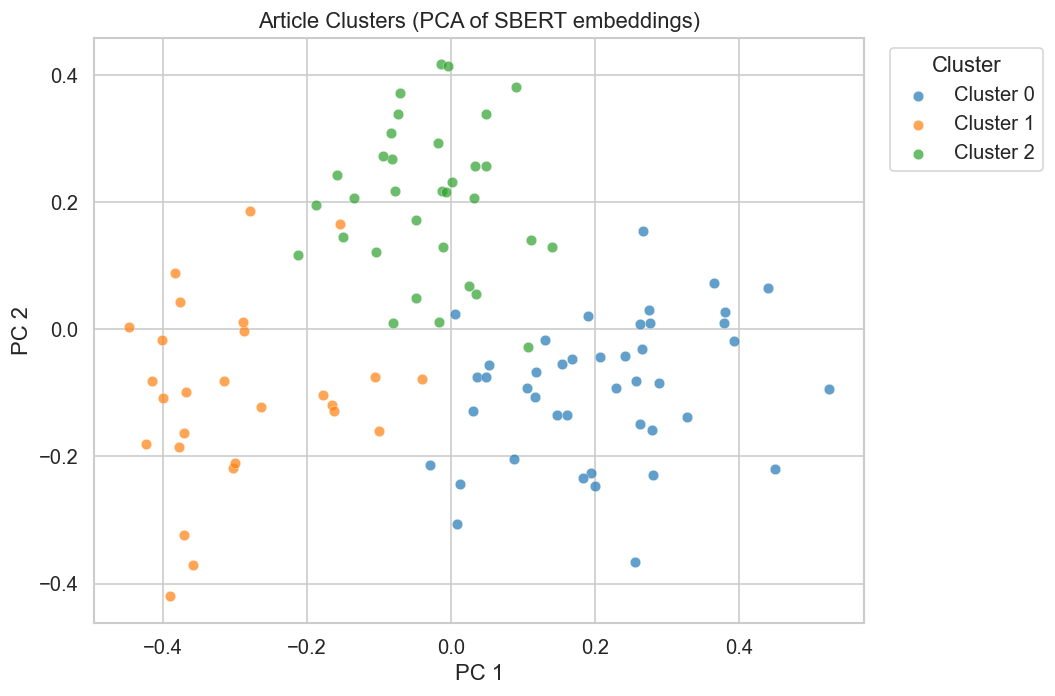

In [166]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tech_embeddings)

fig, ax = plt.subplots(figsize=(9, 6))
palette = sns.color_palette('tab10', N_CLUSTERS)

for c in range(N_CLUSTERS):
    mask = df_tech['cluster'] == c
    ax.scatter(coords[mask, 0], coords[mask, 1],
               label=f'Cluster {c}', color=palette[c],
               alpha=0.7, s=40, edgecolors='white', linewidths=0.3)

ax.set_title('Article Clusters (PCA of SBERT embeddings)')
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [167]:
cluster_labels = {}

k_values = [k for k in range(max(1, N_CLUSTERS - 3), min(10, N_CLUSTERS + 3) + 1)]

for k in k_values:
    print(f'\n=== K = {k} ===')
    
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = kmeans.fit_predict(tech_embeddings)
    
    for c in range(k):
        mask = labels == c
        subset = df_tech.loc[mask, 'tokenized']
        cluster_article_embeddings = tech_embeddings[mask]
        
        if len(subset) == 0:
            continue
        
        vec = TfidfVectorizer(
            max_features=100,
            stop_words=list(STOPWORDS),
            ngram_range=(1, 2),
            min_df=1
        )
        mat = vec.fit_transform(subset)
        tfidf_scores = dict(zip(vec.get_feature_names_out(), mat.mean(axis=0).A1))
        
        keyword_list = list(tfidf_scores.keys())
        keyword_embeddings = sbert.encode(keyword_list, normalize_embeddings=True)
        
        cluster_center = cluster_article_embeddings.mean(axis=0, keepdims=True)
        cluster_center = cluster_center / (np.linalg.norm(cluster_center) + 1e-9)
        
        semantic_relevance = cosine_similarity(keyword_embeddings, cluster_center).flatten()
        
        combined_scores = {}
        for i, kw in enumerate(keyword_list):
            combined_scores[kw] = tfidf_scores[kw] * semantic_relevance[i]
        
        top_kws = sorted(combined_scores, key=combined_scores.get, reverse=True)[:5]
        cluster_labels[(k, c)] = ', '.join(top_kws)
        
        print(f'Cluster {c:>2} ({len(subset):>4} articles): {cluster_labels[(k, c)]}')


=== K = 1 ===
Cluster  0 ( 103 articles): thuê, cập_nhật, nhà_mạng, ai, màn_hình

=== K = 2 ===
Cluster  0 (  70 articles): màn_hình, cập_nhật, dòng, apple, nâng_cấp
Cluster  1 (  33 articles): thuê, xác_thực thuê, nhà_mạng, thuê di_động, xác_thực

=== K = 3 ===
Cluster  0 (  43 articles): màn_hình, iphone, máy, dòng, apple
Cluster  1 (  27 articles): thuê, xác_thực thuê, thuê di_động, xác_thực, nhà_mạng
Cluster  2 (  33 articles): ai, triển_khai, ứng_dụng, nhân_tạo, ios

=== K = 4 ===
Cluster  0 (  38 articles): màn_hình, máy, dòng, samsung, iphone
Cluster  1 (  26 articles): thuê, xác_thực thuê, xác_thực, thuê di_động, nhà_mạng
Cluster  2 (  30 articles): ai, ios, apple, nhân_tạo, tặng
Cluster  3 (   9 articles): dọa, năng_trí thông_minh, tính năng_trí, bản_sao ai, thông_minh cá_nhân

=== K = 5 ===
Cluster  0 (  25 articles): dòng, màn_hình, samsung, thiết_kế, lưu_trữ
Cluster  1 (  26 articles): thuê, xác_thực thuê, thuê di_động, xác_thực, nhà_mạng
Cluster  2 (  26 articles): cập_nh

In [168]:
tfidf_tech = TfidfVectorizer(
    max_features=300, ngram_range=(1, 2),
    stop_words=list(STOPWORDS), token_pattern=r'(?u)\b\w\w+\b', min_df=2,
)
tfidf_tech_matrix = tfidf_tech.fit_transform(df_tech['tokenized'])
tech_tfidf_scores = dict(zip(
    tfidf_tech.get_feature_names_out(),
    tfidf_tech_matrix.mean(axis=0).A1
))

keyword_embeds = sbert.encode(list(tech_tfidf_scores.keys()), normalize_embeddings=True)
query_embed_mean = query_embeddings.mean(axis=0, keepdims=True)
kw_relevance = cosine_similarity(keyword_embeds, query_embed_mean).flatten()

kw_df = pd.DataFrame({
    'keyword': list(tech_tfidf_scores.keys()),
    'tfidf': list(tech_tfidf_scores.values()),
    'semantic': kw_relevance,
})
kw_df['combined'] = kw_df['tfidf'] * kw_df['semantic']
kw_df = kw_df.sort_values('combined', ascending=False).reset_index(drop=True)

print('Top 20 tech-relevant keywords (TF-IDF x semantic):')
kw_df.head(20)

Top 20 tech-relevant keywords (TF-IDF x semantic):


,keyword,tfidf,semantic,combined
0,nhà_mạng,0.038838,0.472528,0.018352
1,iphone,0.053307,0.257053,0.013703
2,thuê,0.070630,0.186855,0.013198
3,ứng_dụng,0.034113,0.290671,0.009916
4,apple,0.045885,0.208341,0.009560
5,thuê di_động,0.036686,0.257499,0.009447
6,xác_thực,0.040608,0.230331,0.009353
7,màn_hình,0.028524,0.321165,0.009161
8,máy_tính,0.021567,0.420443,0.009068
9,cập_nhật,0.035257,0.252938,0.008918


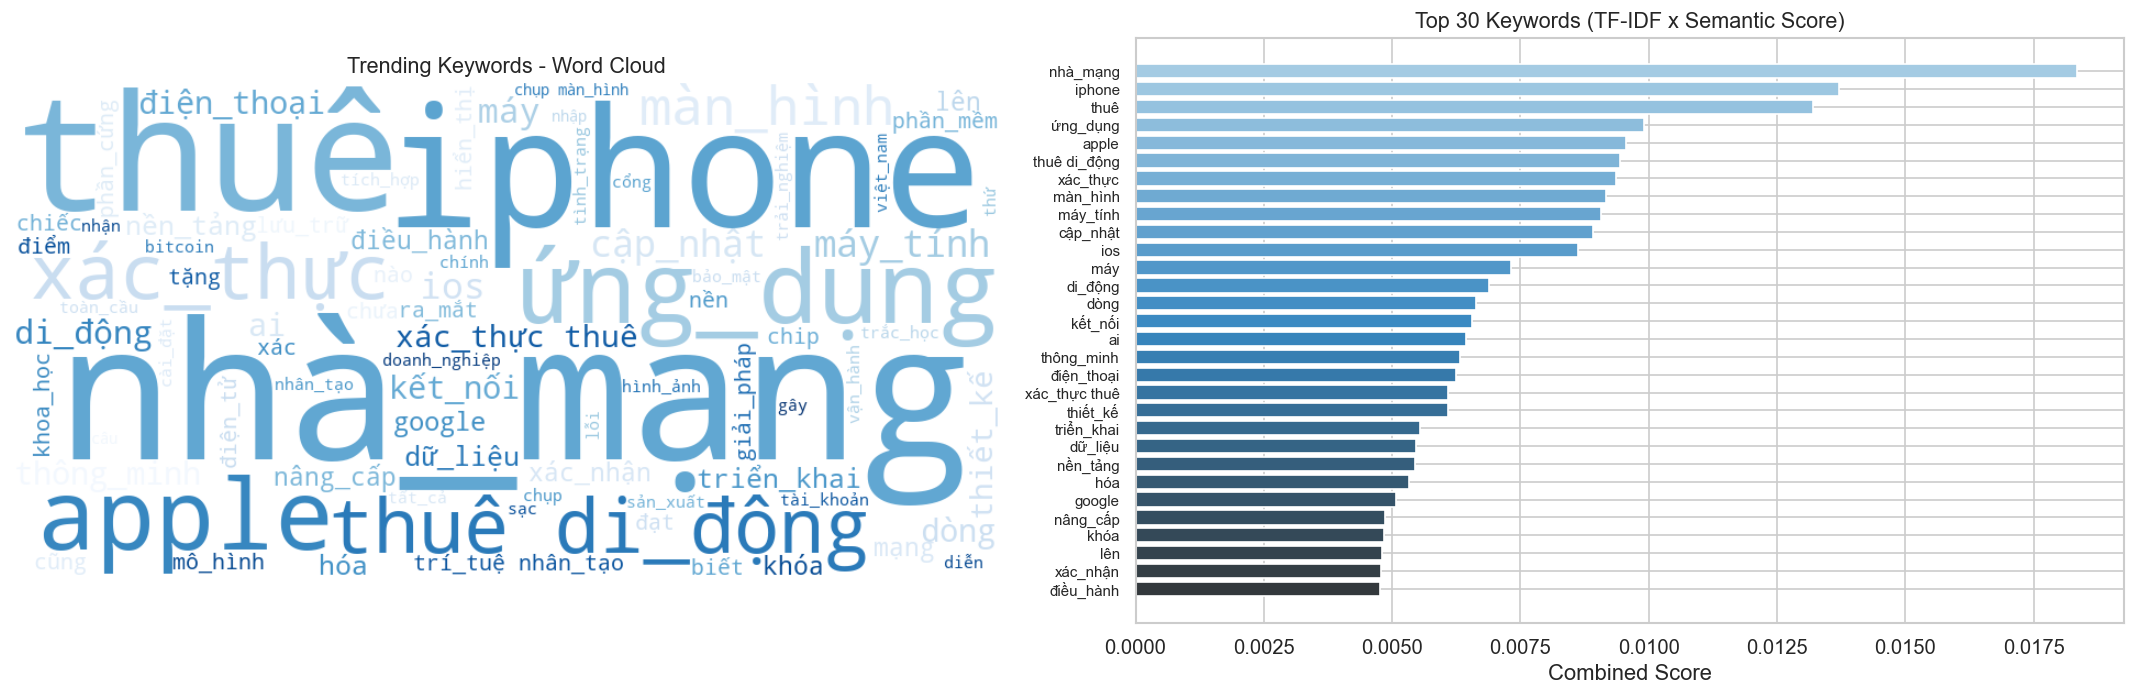

In [169]:
TOP_N  = 30
top_kw = kw_df.head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

wc = WordCloud(width=900, height=450, background_color='white', colormap='Blues', max_words=80)
wc.generate_from_frequencies(dict(zip(kw_df['keyword'], kw_df['combined'])))
axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Trending Keywords - Word Cloud', fontsize=13)

colors = sns.color_palette('Blues_d', TOP_N)
axes[1].barh(top_kw['keyword'][::-1], top_kw['combined'][::-1], color=colors[::-1])
axes[1].set_title(f'Top {TOP_N} Keywords (TF-IDF x Semantic Score)', fontsize=13)
axes[1].set_xlabel('Combined Score')
axes[1].tick_params(axis='y', labelsize=9)

plt.tight_layout()
plt.show()

In [170]:
highlighted = (
    df_tech
    .sort_values('tech_score', ascending=False)
    .groupby('cluster')
    .head(3)
    .sort_values(['cluster', 'tech_score'], ascending=[True, False])
    [['cluster', 'title', 'source', 'published_at', 'tech_score', 'tech_topic', 'url']]
    .reset_index(drop=True)
)